<a href="https://colab.research.google.com/github/KarenKhou/SmartCloset/blob/main/MachineLearning/Colour_Classification_Euclidean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
rgb_shades_df = pd.read_csv('/content/sample_data/colours_rgb_shades(myVersion).csv')

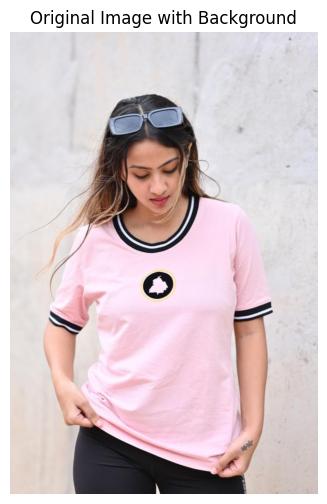

Most frequent color: #f9dbec (Count: 152233)

Closest color name
purple


In [3]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def extract_colors(image_path, num_colors=5):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Initialize GrabCut parameters
    mask = np.zeros(image.shape[:2], np.uint8)
    bgdModel = np.zeros((1, 65), np.float64)
    fgdModel = np.zeros((1, 65), np.float64)
    rect = (10, 10, image.shape[1]-10, image.shape[0]-10)  # Rectangle for GrabCut (change if needed)

    # Apply GrabCut algorithm
    cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
    mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

    # Use mask to separate foreground
    image_fg = image * mask2[:, :, np.newaxis]

    # Apply K-means clustering to find dominant colors in the foreground
    pixels = image_fg[mask2 == 1]  # Get non-zero pixels for color analysis
    kmeans = KMeans(n_clusters=num_colors)
    kmeans.fit(pixels)
    colors = kmeans.cluster_centers_

    # Get the labels assigned to each pixel
    labels = kmeans.labels_

    # Count the occurrences of each label
    counts = np.bincount(labels)

    return colors.astype(int), image, counts  # Return the original image here, not the masked one

# Convert RGB to HEX
def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(rgb[0], rgb[1], rgb[2])

def display_highest_count_color(colors, counts):
    # Sort colors and counts based on counts
    sorted_indices = np.argsort(counts)[::-1]
    sorted_colors = [colors[i] for i in sorted_indices]
    sorted_counts = [counts[i] for i in sorted_indices]

    # Return only the color with the highest count
    most_frequent_color = sorted_colors[0]
    hex_color = rgb_to_hex(most_frequent_color)
    print(f"Most frequent color: {hex_color} (Count: {sorted_counts[0]})")

    return most_frequent_color  # Return only the most frequent color

def find_closest_hex_color(sorted_colors, color_df):
    closest_colors = []
    for color in sorted_colors:
        # Convert RGB to HEX
        hex_color = rgb_to_hex(color)
        hex_color = hex_color.lstrip('#')

        # Calculate the distance to each color in the dataframe
        distances = color_df['RGB Hex'].apply(
            lambda x: sum((int(x[i:i+2], 16) - int(hex_color[i:i+2], 16)) ** 2 for i in (0, 2, 4))
            if len(x) == 6 else float('inf')
        )

        # Get the index of the closest color
        closest_index = distances.idxmin()
        closest_color = color_df.iloc[closest_index]
        closest_colors.append((closest_color['Color Name'], closest_color['RGB Hex']))

    return closest_colors

# Example usage:
query_image_path = "/content/sample_data/PunjabMapPinkGirls.jpg"  # Full path to the image file
colors, original_image, counts = extract_colors(query_image_path)

# Display the original image with the background
plt.figure(figsize=(6, 6))
plt.imshow(original_image)
plt.title("Original Image with Background")
plt.axis('off')
plt.show()

# Display the color with the highest count
highest_count_color = display_highest_count_color(colors, counts)

# Find the closest color name and HEX

closest_color_info = find_closest_hex_color([highest_count_color], rgb_shades_df)

# Output the closest color name and HEX on the image
print("\nClosest color name")
for color_name, hex_color in closest_color_info:
    print(f"{color_name}")
